# exp-h0-xgb-complement-01

## 가설
규정 안전 faithful H0는 구조화 변이와 EB score를 선형 LR 및 LGBM specialist로 해석한다. 동일한 fold-safe 입력을 얕고 강하게 정규화한 XGBoost에 학습하면 일부 비선형 경계를 보완할 수 있다.

## 고정 조건
- 기준: faithful H0를 변경하지 않음
- XGB: `multi:softprob`, 300 trees, learning rate 0.03, depth 4, strong L1/L2 regularization
- 결합: `0.80 × H0 + 0.20 × XGB` 고정. 가중치·threshold 탐색 없음
- Screen: seed 42, Stratified 5-fold. 통과할 때만 같은 실행기에 `42 777 2024`를 전달

## Dacon·팀 규칙
- OOF 실행은 train만 읽으며 test.csv를 읽지 않는다.
- H0의 vocabulary, recurrent event, EB, automatic specialist는 outer-fold train에서만 fit한다.
- 고정 암종명·유전자명·exact mutation 목록을 사용하지 않는다.
- WT, 빈 문자열, NaN은 mutation event를 만들지 않는다.


In [1]:
from pathlib import Path
import json
import subprocess
import sys
from tqdm.auto import tqdm

ROOT = Path('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton')
BASE = ROOT / 'experiments' / 'gs' / 'notebooks' / 'exp_model_007'
RUNNER = BASE / 'common' / 'run_h0_xgb_complement.py'
RESULT = BASE / 'result'
RUN_ID = 'exp-h0-xgb-complement-01'
SEEDS = (42,)  # screen 통과 후 (42, 777, 2024)로 바꾸되 파라미터는 바꾸지 않습니다.
RUN_EXPERIMENT = True
assert RUNNER.exists()
assert (ROOT / 'data' / 'raw' / 'train.csv').exists()
{'runner': RUNNER, 'result_dir': RESULT, 'seeds': SEEDS}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/common/run_h0_xgb_complement.py'),
 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_007/result'),
 'seeds': (42,)}

In [2]:
# 전체 CV 전 smoke test: train schema·XGB config·test 미열람 계약만 확인합니다.
check = subprocess.run([sys.executable, str(RUNNER), '--smoke'], capture_output=True, text=True)
print(check.stdout)
if check.returncode:
    raise RuntimeError(check.stderr)


{"smoke": "ok", "test_read": false, "nan_as_mutation_count": 0, "fixed_class_gene_mutation_rules": false}



In [3]:
if RUN_EXPERIMENT:
    command = [sys.executable, str(RUNNER), '--run-id', RUN_ID, '--seeds', *map(str, SEEDS)]
    process = subprocess.Popen(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    tail = []
    for line in tqdm(process.stdout, desc='faithful H0 + XGB', unit='line'):
        print(line, end='')
        tail = (tail + [line])[-120:]
    if process.wait():
        raise RuntimeError('XGB complement runner failed:\n' + ''.join(tail))
else:
    print('RUN_EXPERIMENT=False: 결과만 읽습니다.')


faithful H0 + XGB: 1line [00:05,  5.15s/line]

[H0-XGB] seed 42, fold 1/5: H0 fit + XGB fit


faithful H0 + XGB: 2line [03:17, 115.05s/line]

[H0-XGB] seed 42, fold 2/5: H0 fit + XGB fit


faithful H0 + XGB: 3line [07:12, 170.19s/line]

...

faithful H0 + XGB: 5line [14:43, 203.94s/line]

[H0-XGB] seed 42, fold 5/5: H0 fit + XGB fit


faithful H0 + XGB: 6line [17:59, 201.32s/line]

{"seeds": [42], "h0_weight": 0.8, "xgb_weight": 0.2, "h0_seed42_reference_delta": -1.4001810832997563e-07, "h0_seed42_reference_match": true, "positive_fold_count": 3, "mean_delta": -0.0006296205974635205, "leakage_check": true, "nan_as_mutation_count": 0, "test_read": false, "decision": "rejected_or_not_detected"}


faithful H0 + XGB: 6line [18:00, 180.04s/line]


In [5]:
import matplotlib.pyplot as plt
import pandas as pd

summary = pd.read_csv(RESULT / f'{RUN_ID}_seed_summary.csv')
aggregate = pd.read_csv(RESULT / f'{RUN_ID}_aggregate_summary.csv')
folds = pd.read_csv(RESULT / f'{RUN_ID}_fold_metrics.csv')
classes = pd.read_csv(RESULT / f'{RUN_ID}_class_metrics.csv')
audit = json.loads((RESULT / f'{RUN_ID}_leakage_audit.json').read_text(encoding='utf-8'))

assert summary.leakage_check.all()
assert summary.nan_as_mutation_count.eq(0).all()
assert audit['test_read'] is False
display(summary.sort_values(['seed', 'variant']))
display(aggregate.sort_values('oof_macro_f1_mean', ascending=False))
audit


,seed,variant,oof_macro_f1,oof_accuracy,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds,delta_vs_h0
0,42,H0,0.544744,0.555556,8193.2,0,True,0,1073.679515,0.000000
2,42,H0_080_XGB_020,0.544114,0.556846,8193.2,0,True,0,1073.727613,-0.000630
1,42,XGB_structured,0.483635,0.522819,8193.2,0,True,0,1073.703038,-0.061109


,variant,seed_count,oof_macro_f1_mean,oof_macro_f1_std,delta_vs_h0_mean,delta_vs_h0_std,feature_count_mean,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H0,1,0.544744,NaN,0.000000,NaN,8193.2,0,True,0
1,H0_080_XGB_020,1,0.544114,NaN,-0.000630,NaN,8193.2,0,True,0
2,XGB_structured,1,0.483635,NaN,-0.061109,NaN,8193.2,0,True,0


{'seeds': [42],
 'h0_weight': 0.8,
 'xgb_weight': 0.2,
 'h0_seed42_reference_delta': -1.4001810832997563e-07,
 'h0_seed42_reference_match': True,
 'positive_fold_count': 3,
 'mean_delta': -0.0006296205974635205,
 'leakage_check': True,
 'nan_as_mutation_count': 0,
 'test_read': False,
 'decision': 'rejected_or_not_detected'}

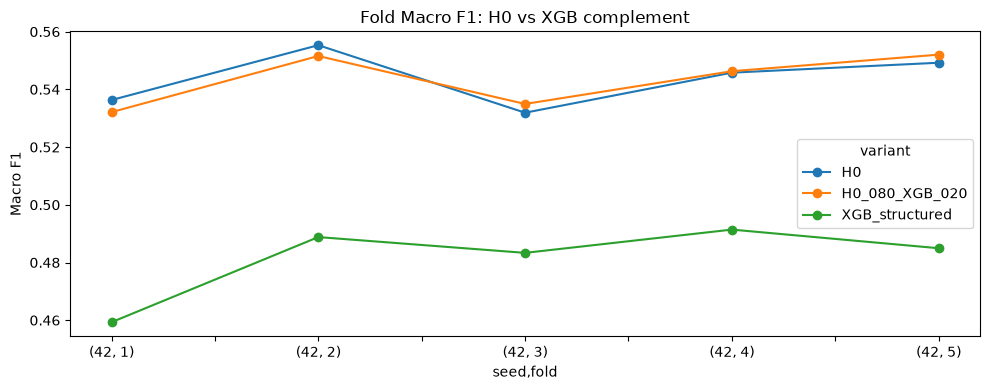

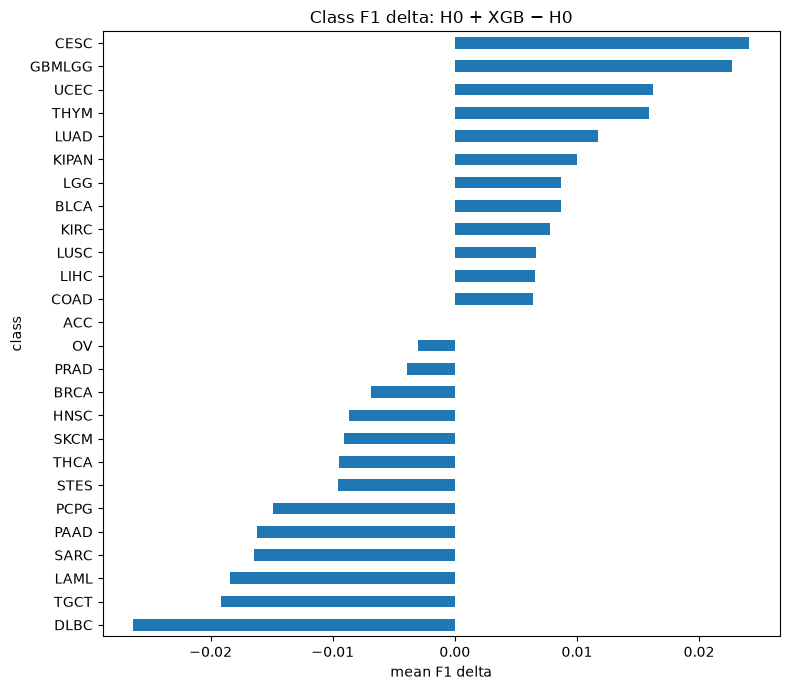

In [6]:
fold_view = folds.pivot_table(index=['seed', 'fold'], columns='variant', values='macro_f1')
ax = fold_view.plot(marker='o', figsize=(10, 4), title='Fold Macro F1: H0 vs XGB complement')
ax.set_ylabel('Macro F1')
plt.tight_layout()
plt.show()

f1_view = classes.pivot_table(index=['seed', 'class'], columns='variant', values='f1')
f1_delta = (f1_view['H0_080_XGB_020'] - f1_view['H0']).groupby('class').mean().sort_values()
ax = f1_delta.plot.barh(figsize=(8, 7), title='Class F1 delta: H0 + XGB − H0')
ax.set_xlabel('mean F1 delta')
plt.tight_layout()
plt.show()


In [7]:
print(f"자동 판정: {audit['decision']}")
print(f"평균 delta: {audit['mean_delta']:+.6f}, 양의 fold: {audit['positive_fold_count']}/5")
print('screen 승격 조건: +0.008 이상, 양의 fold 4/5 이상. 통과 시 SEEDS만 3개로 확장합니다.')


자동 판정: rejected_or_not_detected
평균 delta: -0.000630, 양의 fold: 3/5
screen 승격 조건: +0.008 이상, 양의 fold 4/5 이상. 통과 시 SEEDS만 3개로 확장합니다.
